# 08 — OpenCV Telea Restoration

This notebook generates the deterministic OpenCV Telea restoration baseline
for all applicable controlled restoration datasets.

The notebook processes:

1. canonical damaged-image cases;
2. damage-size sensitivity cases;
3. mask-robustness cases;
4. synthetic-degradation cases for which localized inpainting is
   methodologically appropriate.

For every restoration case, the pipeline records:

- standardized source and restoration identifiers;
- source dataset;
- OpenCV version;
- Telea algorithm and inpainting radius;
- execution runtime;
- generation status and failure reason;
- output path and SHA-256 checksum;
- file validation;
- basic restoration-behavior validation.

The notebook produces dataset-specific restoration folders together with
unified metadata, validation, inventory, runtime, failure, and experiment
summary manifests.

OpenCV Telea is treated as a deterministic classical inpainting baseline.
Its outputs are candidate reconstructions generated through local propagation
from known boundary pixels. They are not interpreted as historically faithful
painting restorations without subsequent evaluation.

In [5]:
from pathlib import Path
import sys


def find_project_root(
    start_path: Path,
) -> Path:
    current_path = start_path.resolve()

    for candidate in (
        current_path,
        *current_path.parents,
    ):
        if (
            candidate
            / "src"
            / "restoration_eval"
        ).exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root "
        "containing src/restoration_eval."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Source directory:",
    SRC_DIR,
)

print(
    "Python executable:",
    sys.executable,
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Python executable: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Scripts\python.exe


In [6]:
import json
import platform
import shutil
from datetime import datetime, timezone

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from restoration_eval.restoration_opencv import (
    DEFAULT_OPENCV_MODEL_NAME,
    DEFAULT_TELEA_RADIUS,
    RESTORATION_GENERATOR_NAME,
    RESTORATION_GENERATOR_VERSION,
    audit_opencv_restoration_inventory,
    calculate_file_sha256,
    create_opencv_restoration_dataset,
    restore_with_opencv_telea,
    summarize_opencv_restoration,
    validate_opencv_restoration_behavior,
    validate_restoration_input_manifest,
    validate_restored_images,
)


pd.set_option(
    "display.max_columns",
    200,
)

pd.set_option(
    "display.width",
    200,
)

print(
    "OpenCV version:",
    cv2.__version__,
)

print(
    "Restoration generator:",
    RESTORATION_GENERATOR_NAME,
)

print(
    "Restoration generator version:",
    RESTORATION_GENERATOR_VERSION,
)

OpenCV version: 4.11.0
Restoration generator: restoration_eval.restoration_opencv
Restoration generator version: 2.0.0


In [7]:
# Discover available metadata manifests

processed_metadata_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
)

if not processed_metadata_dir.is_dir():
    raise FileNotFoundError(
        "Processed metadata directory does not exist: "
        f"{processed_metadata_dir}"
    )


metadata_files = sorted(
    processed_metadata_dir.glob("*.csv")
)


print(
    "Processed metadata directory:",
    processed_metadata_dir,
)

print(
    "\nCSV metadata files found:",
    len(metadata_files),
)

for metadata_path in metadata_files:
    print(
        "-",
        metadata_path.name,
    )

Processed metadata directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata

CSV metadata files found: 11
- metadata_damage_size_sensitivity.csv
- metadata_damaged_images.csv
- metadata_damaged_sdxl_smoke.csv
- metadata_mask_robustness.csv
- metadata_masks.csv
- metadata_processed_clean.csv
- metadata_restored_lama.csv
- metadata_restored_opencv_telea.csv
- metadata_restored_sdxl_smoke.csv
- metadata_restored_stable_diffusion.csv
- metadata_synthetic_degradation.csv


In [8]:
# Inspect available metadata manifests

metadata_inventory_rows = []
metadata_frames = {}


for metadata_path in metadata_files:
    metadata_df = pd.read_csv(
        metadata_path
    )

    metadata_df.columns = (
        metadata_df.columns
        .astype(str)
        .str.strip()
    )

    metadata_frames[
        metadata_path.name
    ] = metadata_df

    metadata_inventory_rows.append(
        {
            "filename": metadata_path.name,
            "rows": len(metadata_df),
            "columns": len(
                metadata_df.columns
            ),
            "column_names": ", ".join(
                metadata_df.columns
            ),
        }
    )


metadata_inventory_df = (
    pd.DataFrame(
        metadata_inventory_rows
    )
    .sort_values(
        "filename"
    )
    .reset_index(
        drop=True
    )
)


display(
    metadata_inventory_df
)

,filename,rows,columns,column_names
0,metadata_damage_size_sensitivity.csv,35,52,"case_id, painting_id, base_mask_id, base_mask_..."
1,metadata_damaged_images.csv,250,31,"case_id, painting_id, mask_id, mask_type, gene..."
2,metadata_damaged_sdxl_smoke.csv,1,19,"case_id, painting_id, mask_id, mask_type, clea..."
3,metadata_mask_robustness.csv,75,97,"case_id, variant_id, robustness_group_id, pain..."
4,metadata_masks.csv,250,66,"case_id, painting_id, mask_id, mask_type, mask..."
5,metadata_processed_clean.csv,50,47,"painting_id, category, title, artist, date, st..."
6,metadata_restored_lama.csv,250,32,"case_id, painting_id, mask_id, mask_type, clea..."
7,metadata_restored_opencv_telea.csv,250,20,"case_id, painting_id, mask_id, mask_type, mode..."
8,metadata_restored_sdxl_smoke.csv,1,32,"case_id, painting_id, mask_id, mask_type, clea..."
9,metadata_restored_stable_diffusion.csv,250,36,"case_id, painting_id, mask_id, mask_type, clea..."


In [9]:
canonical_metadata_df = pd.read_csv(
    processed_metadata_dir
    / "metadata_damaged_images.csv"
)

damage_size_metadata_df = pd.read_csv(
    processed_metadata_dir
    / "metadata_damage_size_sensitivity.csv"
)

mask_robustness_metadata_df = pd.read_csv(
    processed_metadata_dir
    / "metadata_mask_robustness.csv"
)

synthetic_metadata_df = pd.read_csv(
    processed_metadata_dir
    / "metadata_synthetic_degradation.csv"
)


print(
    f"Canonical: {len(canonical_metadata_df)}"
)

print(
    f"Damage Size: {len(damage_size_metadata_df)}"
)

print(
    f"Mask Robustness: {len(mask_robustness_metadata_df)}"
)

print(
    f"Synthetic: {len(synthetic_metadata_df)}"
)

Canonical: 250
Damage Size: 35
Mask Robustness: 75
Synthetic: 105


In [10]:
datasets = {
    "canonical": canonical_metadata_df,
    "damage_size": damage_size_metadata_df,
    "mask_robustness": mask_robustness_metadata_df,
    "synthetic": synthetic_metadata_df,
}

for name, df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print(df.columns.tolist())

    print()

CANONICAL
['case_id', 'painting_id', 'mask_id', 'mask_type', 'generator_name', 'generator_version', 'generated_at_utc', 'generation_action', 'clean_filename', 'clean_path', 'mask_filename', 'mask_path', 'damaged_filename', 'damaged_path', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'damaged_area_pixels', 'damaged_area_percentage_content', 'damaged_area_percentage_full', 'width', 'height', 'mode', 'format', 'damaged_file_size_bytes', 'clean_sha256', 'mask_sha256', 'damaged_sha256', 'status', 'issue']

DAMAGE_SIZE
['case_id', 'painting_id', 'base_mask_id', 'base_mask_type', 'sensitivity_mask_id', 'target_percentage_content', 'target_pixels', 'realised_pixels', 'realised_percentage_content', 'realised_percentage_full', 'percentage_error_content', 'absolute_percentage_error_content', 'absolute_pixel_error', 'scale_factor', 'base_mask_pixels', 'base_percentage_content', 'base_percentage_full', 'content_area_pixels', 'content_bbox_left', 'content_bbox_top', 'co

In [11]:
required_columns = [
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
]

for name, df in datasets.items():

    print("\n", name)

    for column in required_columns:

        print(
            f"{column:<20}",
            column in df.columns,
        )


 canonical
case_id              True
painting_id          True
clean_path           True
damaged_path         True
mask_path            True

 damage_size
case_id              True
painting_id          True
clean_path           True
damaged_path         True
mask_path            False

 mask_robustness
case_id              True
painting_id          True
clean_path           True
damaged_path         True
mask_path            True

 synthetic
case_id              True
painting_id          True
clean_path           True
damaged_path         False
mask_path            False


In [12]:
# Standardize the common restoration interface

manifest_map = {
    "canonical": canonical_metadata_df.copy(),
    "damage_size": damage_size_metadata_df.copy(),
    "mask_robustness": mask_robustness_metadata_df.copy(),
    "synthetic": synthetic_metadata_df.copy(),
}


for dataset_name, df in manifest_map.items():

    df["dataset_name"] = dataset_name

    df["case_id"] = (
        df["case_id"]
        .astype(str)
    )

    df["painting_id"] = (
        df["painting_id"]
        .astype(str)
    )

    manifest_map[dataset_name] = (
        df
    )


print(
    "Prepared manifests:"
)

for name, df in manifest_map.items():

    print(
        f"{name:<18}{len(df):>6} rows"
    )

Prepared manifests:
canonical            250 rows
damage_size           35 rows
mask_robustness       75 rows
synthetic            105 rows


In [18]:
# Normalize path columns using the confirmed dataset schemas

path_column_map = {
    "canonical": {
        "clean_path": "clean_path",
        "damaged_path": "damaged_path",
        "mask_path": "mask_path",
    },
    "damage_size": {
        "clean_path": "clean_path",
        "damaged_path": "damaged_path",
        "mask_path": "sensitivity_mask_path",
    },
    "mask_robustness": {
        "clean_path": "clean_path",
        "damaged_path": "damaged_path",
        "mask_path": "mask_path",
    },
    "synthetic": {
        "clean_path": "clean_path",
        "damaged_path": "degraded_path",
        "mask_path": "effect_mask_path",
    },
}

path_mapping_rows = []

for dataset_name, df in manifest_map.items():
    mapping = path_column_map[dataset_name]

    for target_column, source_column in mapping.items():
        if source_column not in df.columns:
            raise KeyError(
                f"{dataset_name}: missing expected column "
                f"'{source_column}'"
            )

        df[target_column] = (
            df[source_column]
            .astype(str)
            .str.strip()
        )

    manifest_map[dataset_name] = df

    path_mapping_rows.append(
        {
            "dataset": dataset_name,
            "clean_source_column": mapping["clean_path"],
            "damaged_source_column": mapping["damaged_path"],
            "mask_source_column": mapping["mask_path"],
            "rows": len(df),
        }
    )

path_mapping_df = pd.DataFrame(path_mapping_rows)

display(path_mapping_df)

,dataset,clean_source_column,damaged_source_column,mask_source_column,rows
0,canonical,clean_path,damaged_path,mask_path,250
1,damage_size,clean_path,damaged_path,sensitivity_mask_path,35
2,mask_robustness,clean_path,damaged_path,mask_path,75
3,synthetic,clean_path,degraded_path,effect_mask_path,105


In [19]:
# Resolve repository-relative paths and validate file existence

def resolve_project_path(value: str) -> Path:
    normalized_value = str(value).replace("\\", "/")
    path = Path(normalized_value)

    if path.is_absolute():
        return path.resolve()

    return (PROJECT_ROOT / path).resolve()


validation_rows = []

for dataset_name, df in manifest_map.items():
    for column_name in (
        "clean_path",
        "damaged_path",
        "mask_path",
    ):
        resolved_column = f"resolved_{column_name}"

        df[resolved_column] = (
            df[column_name]
            .map(resolve_project_path)
            .map(str)
        )

        exists_mask = (
            df[resolved_column]
            .map(Path)
            .map(Path.is_file)
        )

        validation_rows.append(
            {
                "dataset": dataset_name,
                "path_type": column_name,
                "rows": len(df),
                "files_found": int(exists_mask.sum()),
                "files_missing": int((~exists_mask).sum()),
            }
        )

    manifest_map[dataset_name] = df


file_validation_df = pd.DataFrame(validation_rows)

display(file_validation_df)

,dataset,path_type,rows,files_found,files_missing
0,canonical,clean_path,250,250,0
1,canonical,damaged_path,250,250,0
2,canonical,mask_path,250,250,0
3,damage_size,clean_path,35,35,0
4,damage_size,damaged_path,35,35,0
5,damage_size,mask_path,35,35,0
6,mask_robustness,clean_path,75,75,0
7,mask_robustness,damaged_path,75,75,0
8,mask_robustness,mask_path,75,75,0
9,synthetic,clean_path,105,105,0


In [20]:
# Fail only after showing exact missing-file examples

missing_file_rows = []

for dataset_name, df in manifest_map.items():
    for column_name in (
        "clean_path",
        "damaged_path",
        "mask_path",
    ):
        resolved_column = f"resolved_{column_name}"

        missing_mask = ~(
            df[resolved_column]
            .map(Path)
            .map(Path.is_file)
        )

        if missing_mask.any():
            examples = (
                df.loc[
                    missing_mask,
                    [
                        "case_id",
                        column_name,
                        resolved_column,
                    ],
                ]
                .head(5)
                .copy()
            )

            examples.insert(
                0,
                "dataset",
                dataset_name,
            )

            examples.insert(
                1,
                "path_type",
                column_name,
            )

            missing_file_rows.append(examples)


if missing_file_rows:
    missing_files_df = pd.concat(
        missing_file_rows,
        ignore_index=True,
    )

    display(missing_files_df)

    raise FileNotFoundError(
        "Some referenced files are missing. "
        "See missing_files_df above."
    )

print("All referenced clean, damaged, and mask files exist.")

All referenced clean, damaged, and mask files exist.


In [21]:
# Inspect synthetic degradation cases

synthetic_df = manifest_map[
    "synthetic"
].copy()

degradation_column = next(
    (
        column
        for column in (
            "degradation_type",
            "degradation_name",
            "operator_name",
        )
        if column in synthetic_df.columns
    ),
    None,
)

if degradation_column is None:
    raise KeyError(
        "Synthetic metadata has no recognised "
        "degradation-type column."
    )


synthetic_type_summary_df = (
    synthetic_df
    .groupby(
        degradation_column,
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(
        degradation_column
    )
    .reset_index(
        drop=True
    )
)

print(
    "Synthetic degradation column:",
    degradation_column,
)

display(
    synthetic_type_summary_df
)

Synthetic degradation column: degradation_type


,degradation_type,rows
0,blur,15
1,blur_fading,5
2,dirt_dust,15
3,discolouration,15
4,fading,15
5,fading_discolouration,5
6,partial_transparency,15
7,water_stain,15
8,water_stain_dirt,5


In [22]:
# Select localized synthetic degradation cases for Telea

telea_supported_synthetic_types = {
    "water_stain",
    "dirt_dust",
    "partial_transparency",
    "water_stain_dirt",
}

available_synthetic_types = set(
    synthetic_df[
        degradation_column
    ]
    .dropna()
    .astype(str)
    .unique()
)

selected_synthetic_types = sorted(
    telea_supported_synthetic_types
    & available_synthetic_types
)

synthetic_restoration_df = (
    synthetic_df.loc[
        synthetic_df[
            degradation_column
        ]
        .astype(str)
        .isin(
            selected_synthetic_types
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

synthetic_excluded_df = (
    synthetic_df.loc[
        ~synthetic_df[
            degradation_column
        ]
        .astype(str)
        .isin(
            selected_synthetic_types
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Selected synthetic types:",
    selected_synthetic_types,
)

print(
    "Selected synthetic rows:",
    len(synthetic_restoration_df),
)

print(
    "Excluded synthetic rows:",
    len(synthetic_excluded_df),
)

Selected synthetic types: ['dirt_dust', 'partial_transparency', 'water_stain', 'water_stain_dirt']
Selected synthetic rows: 50
Excluded synthetic rows: 55


In [23]:
# Build unified OpenCV restoration input manifest

restoration_input_frames = [
    manifest_map[
        "canonical"
    ].copy(),
    manifest_map[
        "damage_size"
    ].copy(),
    manifest_map[
        "mask_robustness"
    ].copy(),
    synthetic_restoration_df.copy(),
]

restoration_input_df = pd.concat(
    restoration_input_frames,
    ignore_index=True,
    sort=False,
)

restoration_input_df = (
    restoration_input_df
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

required_restoration_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "resolved_clean_path",
    "resolved_damaged_path",
    "resolved_mask_path",
]

missing_columns = [
    column
    for column in required_restoration_columns
    if column not in restoration_input_df.columns
]

if missing_columns:
    raise KeyError(
        "Unified manifest is missing columns: "
        f"{missing_columns}"
    )


restoration_input_summary_df = (
    restoration_input_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

display(
    restoration_input_summary_df
)

print(
    "Total restoration cases:",
    len(restoration_input_df),
)

display(
    restoration_input_df[
        required_restoration_columns
    ].head()
)

,dataset_name,rows
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic,50


Total restoration cases: 410


,dataset_name,case_id,painting_id,resolved_clean_path,resolved_damaged_path,resolved_mask_path
0,canonical,p001_loss_large,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,p001_loss_small,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical,p001_mixed_damage,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,canonical,p001_scratch_thin,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,canonical,p001_zero_control,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [24]:
# Inspect available restoration-related objects

restoration_objects = {
    name: value
    for name, value in globals().items()
    if any(
        token in name.lower()
        for token in (
            "telea",
            "restore",
            "restoration",
            "inpaint",
        )
    )
}

print("Restoration-related objects found:")

for name, value in sorted(
    restoration_objects.items()
):
    print(
        f"{name:<40} "
        f"{type(value).__name__}"
    )

Restoration-related objects found:
DEFAULT_TELEA_RADIUS                     int
RESTORATION_GENERATOR_NAME               str
RESTORATION_GENERATOR_VERSION            str
TELEA_RADIUS                             int
audit_opencv_restoration_inventory       function
create_opencv_restoration_dataset        function
required_restoration_columns             list
restoration_input_df                     DataFrame
restoration_input_frames                 list
restoration_input_summary_df             DataFrame
restoration_metadata_path                WindowsPath
restoration_root_dir                     WindowsPath
restoration_validation_path              WindowsPath
restore_with_opencv_telea                function
summarize_opencv_restoration             function
synthetic_restoration_df                 DataFrame
telea_supported_synthetic_types          set
validate_opencv_restoration_behavior     function
validate_restoration_input_manifest      function
validate_restored_images            

In [25]:
# Inspect callable signatures before using the module

import inspect


callable_rows = []

for name, value in sorted(
    restoration_objects.items()
):
    if not callable(value):
        continue

    try:
        signature = str(
            inspect.signature(value)
        )
    except (
        TypeError,
        ValueError,
    ):
        signature = "<signature unavailable>"

    try:
        source_file = inspect.getsourcefile(
            value
        )
    except TypeError:
        source_file = None

    callable_rows.append(
        {
            "name": name,
            "signature": signature,
            "source_file": source_file,
        }
    )


restoration_callables_df = pd.DataFrame(
    callable_rows
)

display(
    restoration_callables_df
)

,name,signature,source_file
0,audit_opencv_restoration_inventory,"(restored_metadata: 'pd.DataFrame', restored_r...",D:\Masters\FH\Thesis\painting-restoration-eval...
1,create_opencv_restoration_dataset,"(restoration_input: 'pd.DataFrame', restored_r...",D:\Masters\FH\Thesis\painting-restoration-eval...
2,restore_with_opencv_telea,"(damaged_image_path: 'Path', mask_path: 'Path'...",D:\Masters\FH\Thesis\painting-restoration-eval...
3,summarize_opencv_restoration,(restored_metadata: 'pd.DataFrame') -> 'pd.Dat...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,validate_opencv_restoration_behavior,"(restored_metadata: 'pd.DataFrame', project_ro...",D:\Masters\FH\Thesis\painting-restoration-eval...
5,validate_restoration_input_manifest,(restoration_input: 'pd.DataFrame') -> 'None',D:\Masters\FH\Thesis\painting-restoration-eval...
6,validate_restored_images,"(restored_metadata: 'pd.DataFrame', project_ro...",D:\Masters\FH\Thesis\painting-restoration-eval...


In [26]:
# Display source code for the relevant restoration callables

for name, value in sorted(
    restoration_objects.items()
):
    if not callable(value):
        continue

    print(
        "\n"
        + "=" * 80
    )

    print(name)

    print(
        "=" * 80
    )

    try:
        print(
            inspect.getsource(value)
        )
    except (
        OSError,
        TypeError,
    ) as exc:
        print(
            "Source unavailable:",
            exc,
        )


audit_opencv_restoration_inventory
def audit_opencv_restoration_inventory(
    restored_metadata: pd.DataFrame,
    restored_root_dir: Path,
    project_root: Path | None = None,
) -> pd.DataFrame:
    """Compare metadata-referenced outputs with observed PNG files."""
    required_columns = {
        "restoration_case_id",
        "dataset_name",
        "restored_path",
    }
    missing_columns = sorted(required_columns - set(restored_metadata.columns))
    if missing_columns:
        raise ValueError(
            "Restored metadata is missing inventory columns: "
            f"{missing_columns}"
        )

    expected_paths = {
        _normalise_path(path_value, project_root).resolve()
        for path_value in restored_metadata["restored_path"]
    }
    observed_paths = {
        path.resolve()
        for path in Path(restored_root_dir).rglob("*.png")
        if path.is_file()
    }

    rows: list[dict[str, Any]] = []

    for _, row in restored_metadata.iterrows():
        r

In [27]:
# Prepare the exact manifest consumed by the OpenCV module

opencv_input_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
]

opencv_input_df = (
    restoration_input_df[
        opencv_input_columns
    ]
    .copy()
    .reset_index(drop=True)
)

for column in (
    "dataset_name",
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
):
    opencv_input_df[column] = (
        opencv_input_df[column]
        .astype(str)
        .str.strip()
    )


duplicate_case_mask = (
    opencv_input_df["case_id"]
    .duplicated(keep=False)
)

if duplicate_case_mask.any():
    duplicate_cases_df = (
        opencv_input_df.loc[
            duplicate_case_mask,
            [
                "dataset_name",
                "case_id",
                "painting_id",
            ],
        ]
        .sort_values(
            [
                "case_id",
                "dataset_name",
            ]
        )
        .reset_index(drop=True)
    )

    display(duplicate_cases_df)

    raise ValueError(
        "case_id must be globally unique across the "
        "combined restoration manifest."
    )


validate_restoration_input_manifest(
    opencv_input_df
)

print(
    "OpenCV input manifest validated:",
    len(opencv_input_df),
    "cases",
)

display(
    opencv_input_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .size()
    .rename("cases")
    .reset_index()
)

OpenCV input manifest validated: 410 cases


,dataset_name,cases
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic,50


In [28]:
# Run one controlled smoke test before the full restoration batch

opencv_smoke_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "smoke_tests"
    / "opencv_telea"
)

opencv_smoke_input_df = (
    opencv_input_df
    .iloc[[0]]
    .copy()
)

opencv_smoke_metadata_df = (
    create_opencv_restoration_dataset(
        restoration_input=opencv_smoke_input_df,
        restored_root_dir=opencv_smoke_output_dir,
        project_root=PROJECT_ROOT,
        model_name="opencv_telea_smoke",
        radius=3,
        overwrite=True,
        compute_checksums=True,
    )
)

display(
    opencv_smoke_metadata_df[
        [
            "dataset_name",
            "case_id",
            "model_name",
            "inpaint_radius",
            "restored_path",
            "runtime_seconds",
            "status",
            "issue",
        ]
    ]
)

if not (
    opencv_smoke_metadata_df["status"]
    == "ok"
).all():
    raise RuntimeError(
        "OpenCV Telea smoke test failed."
    )

,dataset_name,case_id,model_name,inpaint_radius,restored_path,runtime_seconds,status,issue
0,canonical,p001_loss_large,opencv_telea_smoke,3,outputs\smoke_tests\opencv_telea\canonical\p00...,1.028233,ok,


,restoration_case_id,dataset_name,case_id,painting_id,restored_path,file_exists,readable,width,height,mode,checksum_matches,validation_passed,issue
0,opencv_telea_smoke__canonical__p001_loss_large,canonical,p001_loss_large,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,


,restoration_case_id,dataset_name,case_id,painting_id,mask_area_pixels,changed_pixels_vs_damaged,changed_pixels_inside_mask,changed_pixels_outside_mask,outside_mask_preserved,empty_mask_unchanged,nonempty_mask_changed,behavior_validation_passed,issue
0,opencv_telea_smoke__canonical__p001_loss_large,canonical,p001_loss_large,p001,69018,69018,69018,0,True,None,True,True,


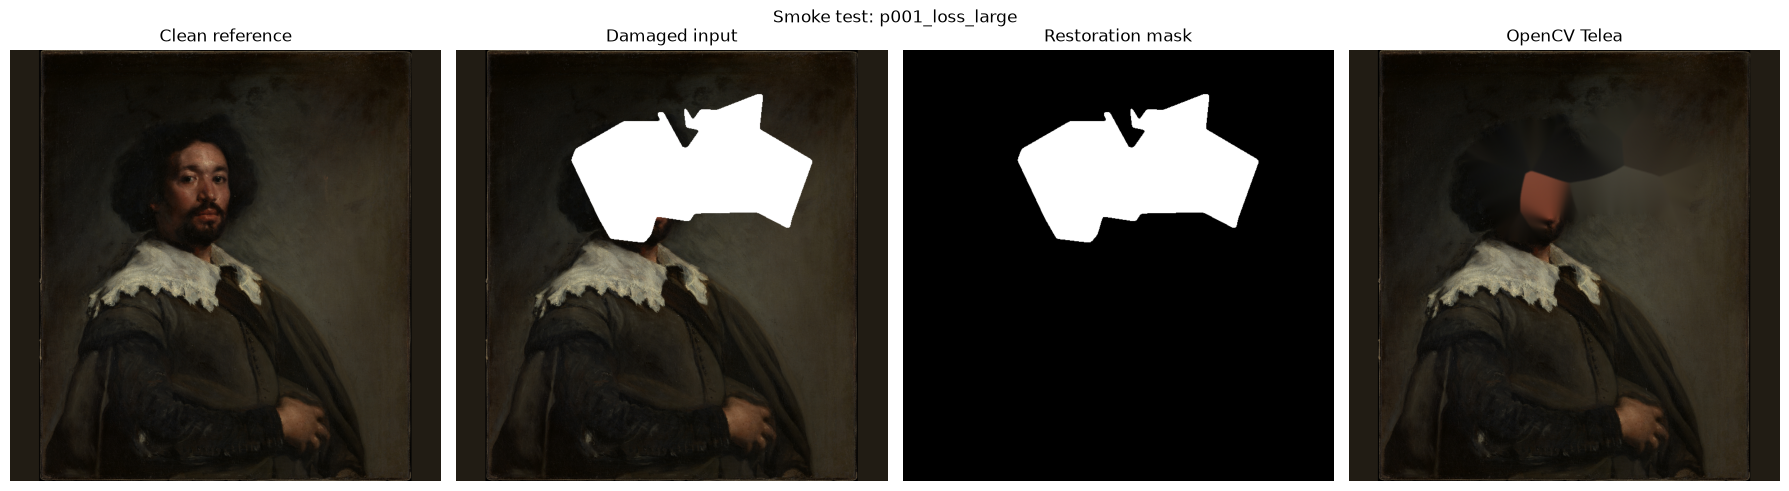

In [29]:
# Validate and visually inspect the smoke-test restoration

import matplotlib.pyplot as plt


opencv_smoke_file_validation_df = (
    validate_restored_images(
        restored_metadata=opencv_smoke_metadata_df,
        project_root=PROJECT_ROOT,
        target_size=768,
    )
)

opencv_smoke_behavior_df = (
    validate_opencv_restoration_behavior(
        restored_metadata=opencv_smoke_metadata_df,
        project_root=PROJECT_ROOT,
        target_size=768,
    )
)

display(
    opencv_smoke_file_validation_df
)

display(
    opencv_smoke_behavior_df
)


smoke_row = opencv_smoke_metadata_df.iloc[0]

clean_image = Image.open(
    resolve_project_path(
        smoke_row["clean_path"]
    )
).convert("RGB")

damaged_image = Image.open(
    resolve_project_path(
        smoke_row["damaged_path"]
    )
).convert("RGB")

mask_image = Image.open(
    resolve_project_path(
        smoke_row["mask_path"]
    )
).convert("L")

restored_image = Image.open(
    resolve_project_path(
        smoke_row["restored_path"]
    )
).convert("RGB")


figure, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5),
)

images = [
    clean_image,
    damaged_image,
    mask_image,
    restored_image,
]

titles = [
    "Clean reference",
    "Damaged input",
    "Restoration mask",
    "OpenCV Telea",
]

for axis, image, title in zip(
    axes,
    images,
    titles,
):
    axis.imshow(
        image,
        cmap="gray"
        if title == "Restoration mask"
        else None,
    )
    axis.set_title(title)
    axis.axis("off")

figure.suptitle(
    f"Smoke test: {smoke_row['case_id']}"
)

plt.tight_layout()
plt.show()

In [30]:
# Run the complete OpenCV Telea restoration batch

opencv_output_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "restored"
    / "opencv_telea"
)

opencv_restored_metadata_df = (
    create_opencv_restoration_dataset(
        restoration_input=opencv_input_df,
        restored_root_dir=opencv_output_dir,
        project_root=PROJECT_ROOT,
        model_name="opencv_telea",
        radius=3,
        overwrite=True,
        compute_checksums=True,
    )
)

display(
    opencv_restored_metadata_df
    .groupby(
        [
            "dataset_name",
            "status",
        ],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

print(
    "Total restoration rows:",
    len(opencv_restored_metadata_df),
)

,dataset_name,status,rows
0,canonical,ok,250
1,damage_size,ok,35
2,mask_robustness,ok,75
3,synthetic,ok,50


Total restoration rows: 410


In [31]:
# Validate all generated OpenCV Telea restorations

opencv_file_validation_df = (
    validate_restored_images(
        restored_metadata=opencv_restored_metadata_df,
        project_root=PROJECT_ROOT,
        target_size=768,
    )
)

opencv_behavior_validation_df = (
    validate_opencv_restoration_behavior(
        restored_metadata=opencv_restored_metadata_df,
        project_root=PROJECT_ROOT,
        target_size=768,
    )
)

print("File validation")

display(
    opencv_file_validation_df
)

print("Restoration behavior validation")

display(
    opencv_behavior_validation_df
)

File validation


,restoration_case_id,dataset_name,case_id,painting_id,restored_path,file_exists,readable,width,height,mode,checksum_matches,validation_passed,issue
0,opencv_telea__canonical__p001_loss_large,canonical,p001_loss_large,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
1,opencv_telea__canonical__p001_loss_small,canonical,p001_loss_small,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
2,opencv_telea__canonical__p001_mixed_damage,canonical,p001_mixed_damage,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
3,opencv_telea__canonical__p001_scratch_thin,canonical,p001_scratch_thin,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
4,opencv_telea__canonical__p001_zero_control,canonical,p001_zero_control,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,opencv_telea__synthetic__p043__partial_transpa...,synthetic,p043__partial_transparency__severe,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
406,opencv_telea__synthetic__p043__water_stain__mild,synthetic,p043__water_stain__mild,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
407,opencv_telea__synthetic__p043__water_stain__mo...,synthetic,p043__water_stain__moderate,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
408,opencv_telea__synthetic__p043__water_stain__se...,synthetic,p043__water_stain__severe,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,


Restoration behavior validation


,restoration_case_id,dataset_name,case_id,painting_id,mask_area_pixels,changed_pixels_vs_damaged,changed_pixels_inside_mask,changed_pixels_outside_mask,outside_mask_preserved,empty_mask_unchanged,nonempty_mask_changed,behavior_validation_passed,issue
0,opencv_telea__canonical__p001_loss_large,canonical,p001_loss_large,p001,69018,69018,69018,0,True,None,True,True,
1,opencv_telea__canonical__p001_loss_small,canonical,p001_loss_small,p001,18239,18239,18239,0,True,None,True,True,
2,opencv_telea__canonical__p001_mixed_damage,canonical,p001_mixed_damage,p001,45733,45733,45733,0,True,None,True,True,
3,opencv_telea__canonical__p001_scratch_thin,canonical,p001_scratch_thin,p001,12058,12058,12058,0,True,None,True,True,
4,opencv_telea__canonical__p001_zero_control,canonical,p001_zero_control,p001,0,0,0,0,True,True,None,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,opencv_telea__synthetic__p043__partial_transpa...,synthetic,p043__partial_transparency__severe,p043,202937,202875,202875,0,True,None,True,True,
406,opencv_telea__synthetic__p043__water_stain__mild,synthetic,p043__water_stain__mild,p043,6506,6497,6497,0,True,None,True,True,
407,opencv_telea__synthetic__p043__water_stain__mo...,synthetic,p043__water_stain__moderate,p043,0,0,0,0,True,True,None,True,
408,opencv_telea__synthetic__p043__water_stain__se...,synthetic,p043__water_stain__severe,p043,23805,23790,23790,0,True,None,True,True,


In [32]:
# Check failures and summarize restoration runtime

failed_restoration_df = (
    opencv_restored_metadata_df.loc[
        opencv_restored_metadata_df[
            "status"
        ] != "ok"
    ]
    .copy()
    .reset_index(drop=True)
)

if not failed_restoration_df.empty:
    display(
        failed_restoration_df[
            [
                "dataset_name",
                "case_id",
                "painting_id",
                "status",
                "issue",
            ]
        ]
    )

    raise RuntimeError(
        f"{len(failed_restoration_df)} "
        "OpenCV Telea restorations failed."
    )


opencv_runtime_summary_df = (
    opencv_restored_metadata_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .agg(
        cases=("case_id", "size"),
        total_seconds=(
            "runtime_seconds",
            "sum",
        ),
        mean_seconds=(
            "runtime_seconds",
            "mean",
        ),
        median_seconds=(
            "runtime_seconds",
            "median",
        ),
        max_seconds=(
            "runtime_seconds",
            "max",
        ),
    )
    .reset_index()
)

display(
    opencv_runtime_summary_df
)

print(
    "All OpenCV Telea restorations "
    "completed successfully."
)

,dataset_name,cases,total_seconds,mean_seconds,median_seconds,max_seconds
0,canonical,250,110.526884,0.442108,0.438963,0.713457
1,damage_size,35,17.438048,0.498230,0.470124,0.756030
2,mask_robustness,75,35.784261,0.477123,0.448460,0.695859
3,synthetic,50,23.647079,0.472942,0.430047,1.166787


All OpenCV Telea restorations completed successfully.


In [33]:
# Split canonical and supplementary restoration metadata

opencv_canonical_metadata_df = (
    opencv_restored_metadata_df.loc[
        opencv_restored_metadata_df[
            "dataset_name"
        ] == "canonical"
    ]
    .copy()
    .reset_index(drop=True)
)

opencv_supplementary_metadata = {
    dataset_name: (
        opencv_restored_metadata_df.loc[
            opencv_restored_metadata_df[
                "dataset_name"
            ] == dataset_name
        ]
        .copy()
        .reset_index(drop=True)
    )
    for dataset_name in (
        "damage_size",
        "mask_robustness",
        "synthetic",
    )
}


output_count_rows = [
    {
        "output": "canonical",
        "rows": len(
            opencv_canonical_metadata_df
        ),
    }
]

output_count_rows.extend(
    {
        "output": dataset_name,
        "rows": len(dataset_df),
    }
    for dataset_name, dataset_df
    in opencv_supplementary_metadata.items()
)

opencv_output_counts_df = pd.DataFrame(
    output_count_rows
)

display(opencv_output_counts_df)


if len(opencv_canonical_metadata_df) != 250:
    raise ValueError(
        "Expected 250 canonical OpenCV rows, "
        f"found {len(opencv_canonical_metadata_df)}."
    )

,output,rows
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic,50


In [34]:
# Save canonical and supplementary OpenCV metadata

metadata_output_paths = {
    "canonical": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea.csv"
    ),
    "damage_size": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_damage_size.csv"
    ),
    "mask_robustness": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_mask_robustness.csv"
    ),
    "synthetic": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_synthetic.csv"
    ),
}


opencv_canonical_metadata_df.to_csv(
    metadata_output_paths["canonical"],
    index=False,
)

for dataset_name, dataset_df in (
    opencv_supplementary_metadata.items()
):
    dataset_df.to_csv(
        metadata_output_paths[
            dataset_name
        ],
        index=False,
    )


saved_metadata_rows = []

for dataset_name, output_path in (
    metadata_output_paths.items()
):
    saved_metadata_rows.append(
        {
            "dataset": dataset_name,
            "path": str(
                output_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": output_path.is_file(),
            "size_bytes": (
                output_path.stat().st_size
                if output_path.is_file()
                else 0
            ),
        }
    )

saved_metadata_df = pd.DataFrame(
    saved_metadata_rows
)

display(saved_metadata_df)

,dataset,path,exists,size_bytes
0,canonical,data\processed\metadata\metadata_restored_open...,True,150736
1,damage_size,data\processed\metadata\metadata_restored_open...,True,26210
2,mask_robustness,data\processed\metadata\metadata_restored_open...,True,55823
3,synthetic,data\processed\metadata\metadata_restored_open...,True,37171


In [36]:
# Reload saved metadata and verify row counts

expected_saved_rows = {
    "canonical": len(
        opencv_canonical_metadata_df
    ),
    **{
        dataset_name: len(dataset_df)
        for dataset_name, dataset_df
        in opencv_supplementary_metadata.items()
    },
}

reload_validation_rows = []

for dataset_name, metadata_path in (
    metadata_output_paths.items()
):
    reloaded_df = pd.read_csv(
        metadata_path
    )

    expected_rows = expected_saved_rows[
        dataset_name
    ]

    actual_rows = len(
        reloaded_df
    )

    reload_validation_rows.append(
        {
            "dataset": dataset_name,
            "expected_rows": expected_rows,
            "reloaded_rows": actual_rows,
            "matches": (
                actual_rows
                == expected_rows
            ),
        }
    )


metadata_reload_validation_df = (
    pd.DataFrame(
        reload_validation_rows
    )
)

display(
    metadata_reload_validation_df
)


if not metadata_reload_validation_df[
    "matches"
].all():
    raise RuntimeError(
        "One or more saved metadata files "
        "failed row-count verification."
    )

print(
    "All OpenCV Telea metadata files "
    "saved and reloaded successfully."
)

,dataset,expected_rows,reloaded_rows,matches
0,canonical,250,250,True
1,damage_size,35,35,True
2,mask_robustness,75,75,True
3,synthetic,50,50,True


All OpenCV Telea metadata files saved and reloaded successfully.


In [37]:
# Select one representative case from each dataset

representative_restoration_df = (
    opencv_restored_metadata_df.loc[
        opencv_restored_metadata_df[
            "status"
        ] == "ok"
    ]
    .sort_values(
        [
            "dataset_name",
            "case_id",
        ],
        kind="stable",
    )
    .groupby(
        "dataset_name",
        as_index=False,
        sort=True,
    )
    .head(1)
    .reset_index(drop=True)
)

representative_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]

display(
    representative_restoration_df[
        representative_columns
    ]
)

,dataset_name,case_id,painting_id,clean_path,damaged_path,mask_path,restored_path
0,canonical,p001_loss_large,p001,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_large_damaged.png,data\processed\masks\p001_loss_large_mask.png,data\processed\restored\opencv_telea\canonical...
1,damage_size,p001__loss_large__size_02pct,p001,data/processed/clean/p001_clean.png,data/processed/damaged/damage_size_sensitivity...,data/processed/masks/damage_size_sensitivity/p...,data\processed\restored\opencv_telea\damage_si...
2,mask_robustness,p001__loss_large__variant_01,p001,data/processed/clean/p001_clean.png,data/processed/damaged/mask_robustness/p001__l...,data/processed/masks/mask_robustness/p001__los...,data\processed\restored\opencv_telea\mask_robu...
3,synthetic,p001__dirt_dust__mild,p001,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/...,data/processed/masks/synthetic_degradation/p00...,data\processed\restored\opencv_telea\synthetic...


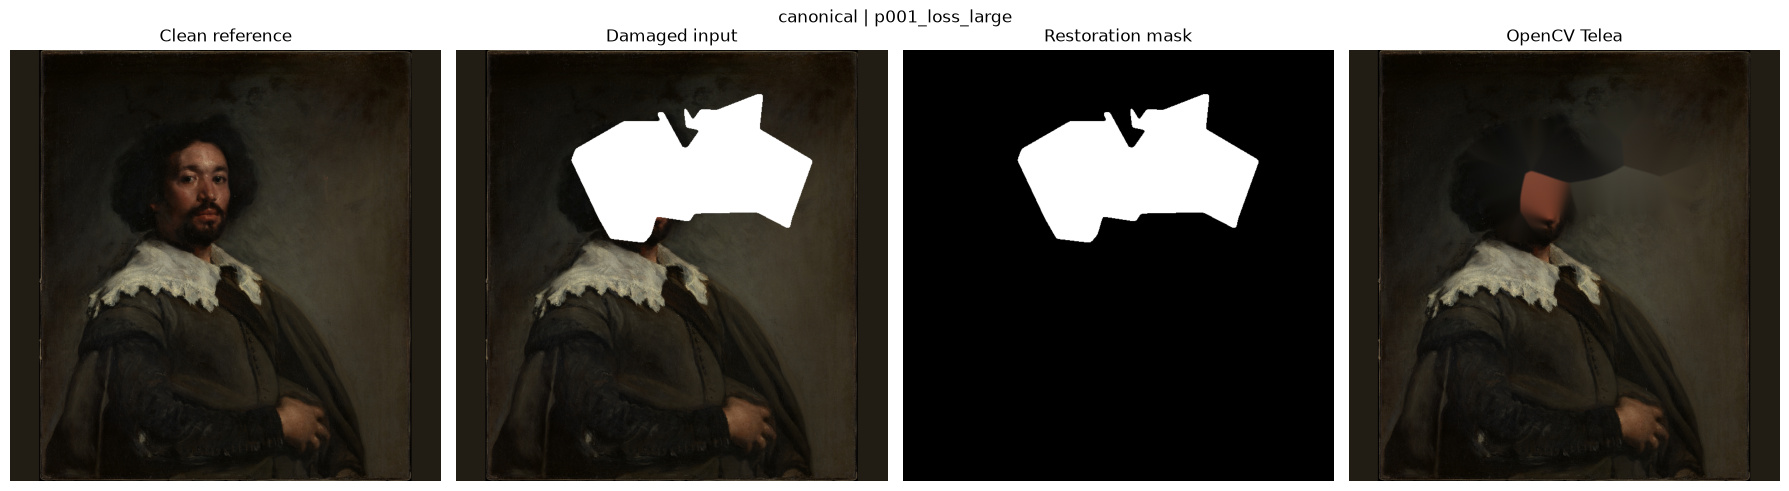

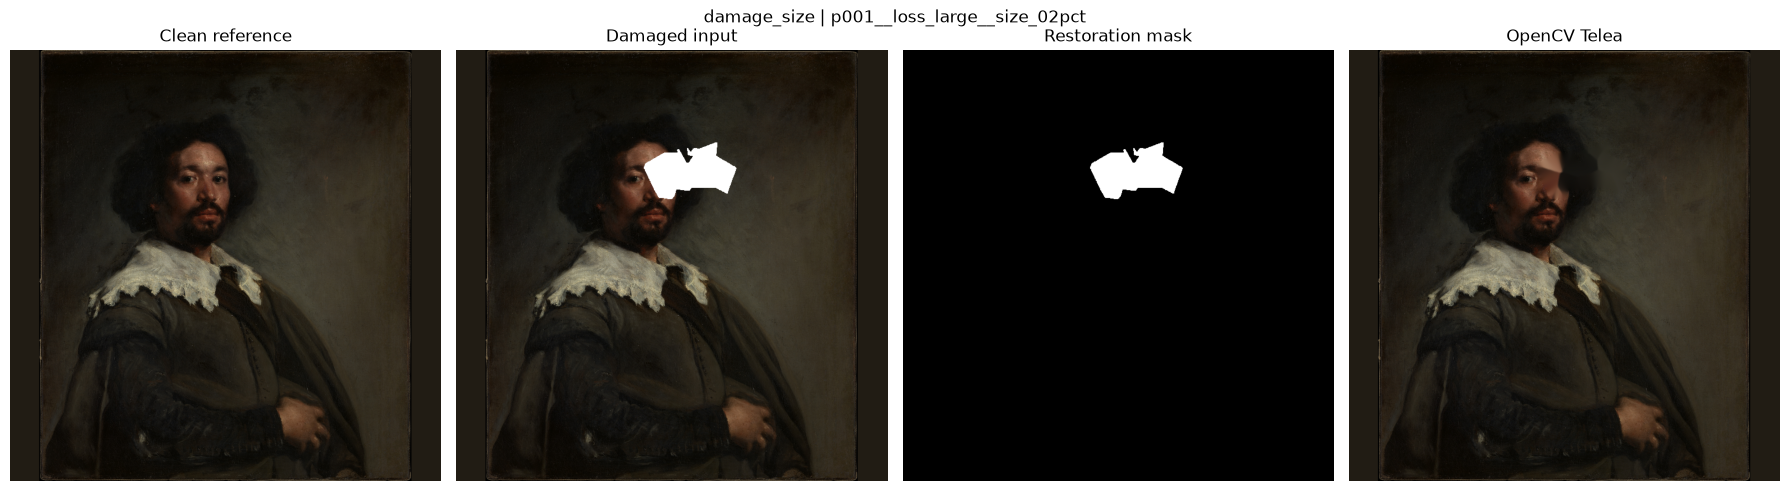

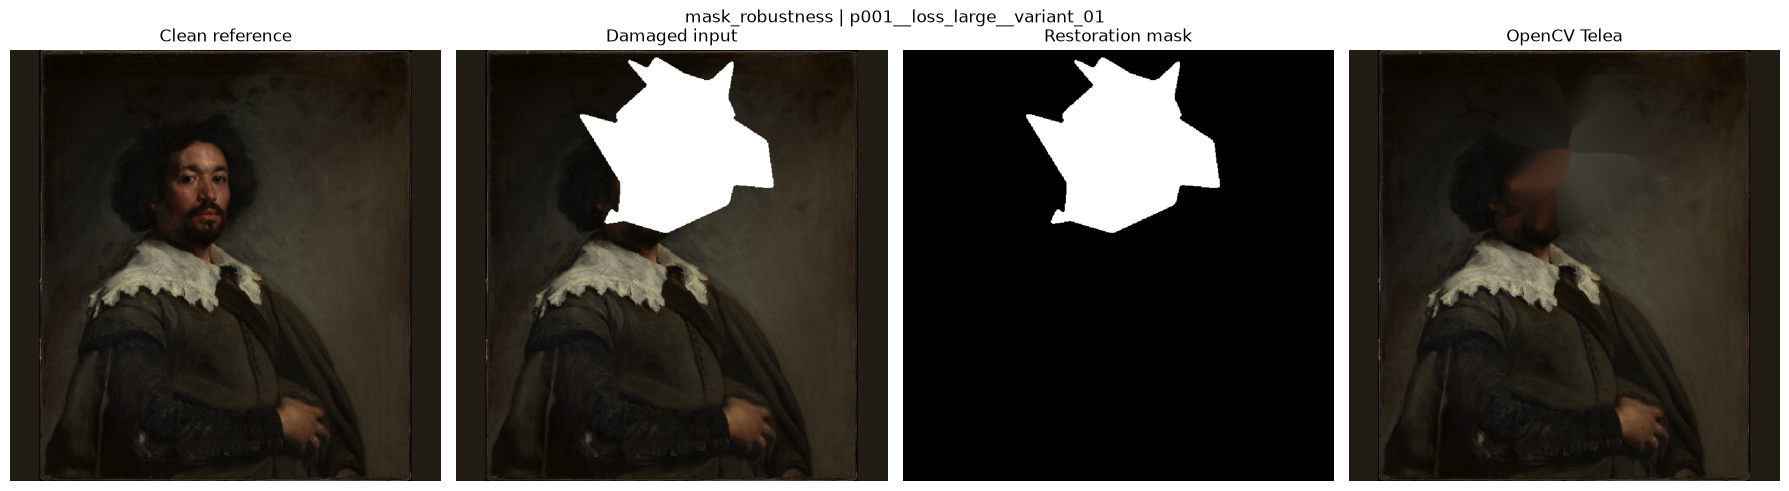

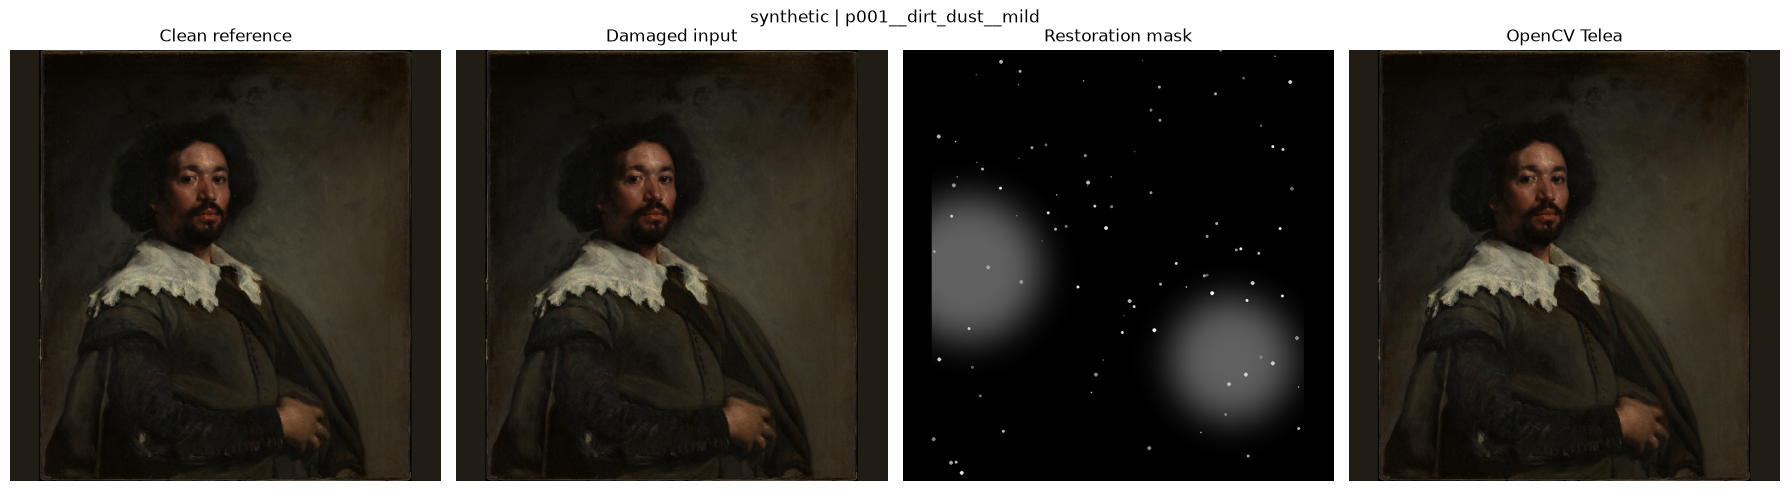

In [38]:
# Display representative OpenCV Telea restorations

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image


def resolve_notebook_path(
    path_value,
):
    path = Path(
        str(path_value)
    )

    if path.is_absolute():
        return path

    return (
        PROJECT_ROOT
        / path
    ).resolve()


for _, row in (
    representative_restoration_df
    .iterrows()
):
    clean_image = Image.open(
        resolve_notebook_path(
            row["clean_path"]
        )
    ).convert("RGB")

    damaged_image = Image.open(
        resolve_notebook_path(
            row["damaged_path"]
        )
    ).convert("RGB")

    mask_image = Image.open(
        resolve_notebook_path(
            row["mask_path"]
        )
    ).convert("L")

    restored_image = Image.open(
        resolve_notebook_path(
            row["restored_path"]
        )
    ).convert("RGB")

    figure, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5),
    )

    images = [
        clean_image,
        damaged_image,
        mask_image,
        restored_image,
    ]

    titles = [
        "Clean reference",
        "Damaged input",
        "Restoration mask",
        "OpenCV Telea",
    ]

    for axis, image, title in zip(
        axes,
        images,
        titles,
    ):
        axis.imshow(
            image,
            cmap=(
                "gray"
                if title
                == "Restoration mask"
                else None
            ),
        )

        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        (
            f"{row['dataset_name']} | "
            f"{row['case_id']}"
        )
    )

    plt.tight_layout()
    plt.show()

In [39]:
# Final integrity checks and notebook summary

expected_total_rows = len(
    opencv_input_df
)

actual_total_rows = len(
    opencv_restored_metadata_df
)

successful_rows = int(
    (
        opencv_restored_metadata_df[
            "status"
        ]
        == "ok"
    ).sum()
)


restored_file_exists = (
    opencv_restored_metadata_df[
        "restored_path"
    ]
    .map(resolve_notebook_path)
    .map(Path.is_file)
)

saved_metadata_exists = {
    dataset_name: path.is_file()
    for dataset_name, path
    in metadata_output_paths.items()
}


final_summary_df = pd.DataFrame(
    [
        {
            "check": "Input rows processed",
            "expected": expected_total_rows,
            "actual": actual_total_rows,
            "passed": (
                actual_total_rows
                == expected_total_rows
            ),
        },
        {
            "check": "Successful restorations",
            "expected": expected_total_rows,
            "actual": successful_rows,
            "passed": (
                successful_rows
                == expected_total_rows
            ),
        },
        {
            "check": "Restored image files exist",
            "expected": expected_total_rows,
            "actual": int(
                restored_file_exists.sum()
            ),
            "passed": bool(
                restored_file_exists.all()
            ),
        },
        {
            "check": "Metadata files saved",
            "expected": len(
                metadata_output_paths
            ),
            "actual": sum(
                saved_metadata_exists.values()
            ),
            "passed": all(
                saved_metadata_exists.values()
            ),
        },
    ]
)

display(final_summary_df)


if not final_summary_df[
    "passed"
].all():
    raise RuntimeError(
        "Notebook 08 final integrity "
        "checks failed."
    )


print(
    "Notebook 08 completed successfully."
)

print(
    f"Generated {successful_rows} "
    "OpenCV Telea restorations."
)

print(
    "Canonical metadata:",
    metadata_output_paths[
        "canonical"
    ].relative_to(
        PROJECT_ROOT
    ),
)

,check,expected,actual,passed
0,Input rows processed,410,410,True
1,Successful restorations,410,410,True
2,Restored image files exist,410,410,True
3,Metadata files saved,4,4,True


Notebook 08 completed successfully.
Generated 410 OpenCV Telea restorations.
Canonical metadata: data\processed\metadata\metadata_restored_opencv_telea.csv


## Summary

This notebook generates OpenCV Telea baseline restorations for the painting restoration evaluation framework. It loads and validates the restoration input metadata, combines the canonical, damage size sensitivity, mask robustness, and supported synthetic degradation datasets into a unified restoration manifest, and executes OpenCV Telea inpainting using the shared restoration pipeline developed in the previous notebook.

The notebook performs comprehensive validation throughout the workflow, including metadata integrity checks, path validation, smoke testing, full-batch restoration validation, restoration behaviour verification, and final output integrity checks. Representative restoration examples are displayed for visual inspection to ensure that modifications remain confined to the intended damaged regions.

The generated restorations are stored in the processed restoration directory, while restoration metadata is exported separately for the canonical dataset and each supplementary evaluation dataset. These outputs serve as the classical computer vision baseline for subsequent quantitative evaluation and comparison against deep learning-based restoration models such as LaMa, Stable Diffusion, and SDXL.